In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from tqdm import tqdm

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [3]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4900.64it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
embeddings = model.embeddings.word_embeddings.weight.detach()

print(f'Embedding matrix shape: {embeddings.shape}')


Embedding matrix shape: torch.Size([30522, 768])


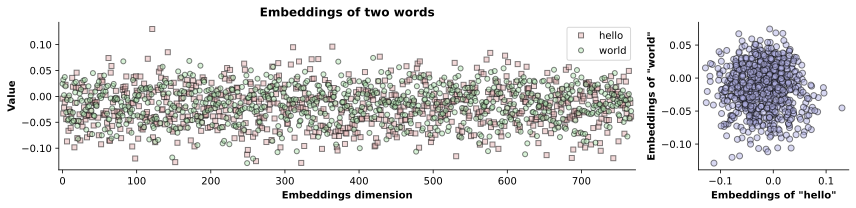

In [7]:
word1 = 'hello'
word2 = 'world'

token1 = tokenizer.encode(word1, add_special_tokens=False)
token2 = tokenizer.encode(word2, add_special_tokens=False)

emb1 = embeddings[token1, :].squeeze()
emb2 = embeddings[token2, :].squeeze()

fig = plt.figure(figsize=(12,3))
gs = gridspec.GridSpec(1, 4, figure=fig)
ax1 = fig.add_subplot(gs[:3])
ax2 = fig.add_subplot(gs[-1])

ax1.plot(emb1, 'ks', markerfacecolor=[.9, .7, .7, .5], markersize=5, label=word1)
ax1.plot(emb2, 'ko', markerfacecolor=[.7, .9, .7, .5], markersize=5, label=word2)

ax1.set(xlabel='Embeddings dimension', ylabel='Value', xlim=[-5, len(emb1)+5], title='Embeddings of two words')
ax1.legend()

ax2.plot(emb1, emb2, 'ko', markerfacecolor=[.7, .7, .9, .5])
ax2.set(xlabel=f'Embeddings of "{word1}"', ylabel=f'Embeddings of "{word2}"')

plt.tight_layout()
plt.savefig('ch3_embeddingsA.png')
plt.show()

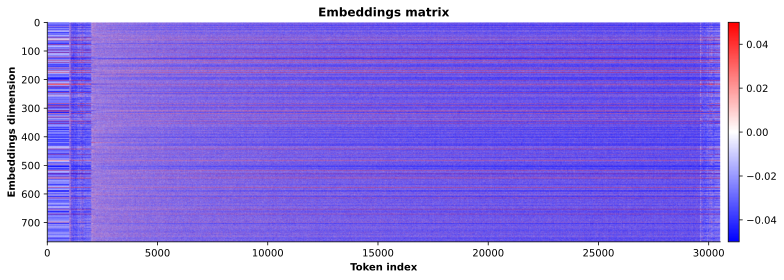

In [8]:
plt.figure(figsize=(12,4))
plt.imshow(embeddings.T, vmin=-0.05, vmax=0.05, aspect='auto', cmap='bwr')

plt.gca().set(xlabel='Token index', ylabel='Embeddings dimension', title='Embeddings matrix')

plt.colorbar(pad=0.01)
plt.tight_layout()
plt.savefig('ch3_embeddingsB.png')
plt.show()

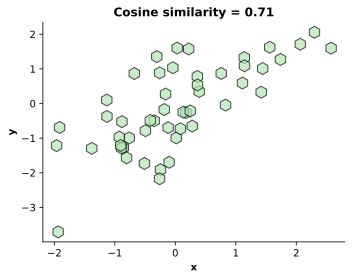

In [9]:
x = np.random.randn(50)
y = x + np.random.randn(50)

num = np.sum(x*y)
norm_x = np.sum(x**2)
norm_y = np.sum(y**2)
den = np.sqrt(norm_x*norm_y)
cs = num/den

plt.figure(figsize=(5,4))
plt.plot(x, y, 'kh', markerfacecolor=[.7, .9, .7, .7], markersize=12)
plt.gca().set(xlabel='x', ylabel='y', title=f'Cosine similarity = {cs:.2f}')

plt.tight_layout()
plt.savefig('ch3_cossimA.png')
plt.show()

In [10]:
n = 100
m = 15

X = np.random.randn(n, m) + np.linspace(-2, 2, m)
X_norm = X / np.linalg.norm(X, axis=0, keepdims=True)

csM = X_norm.T @ X_norm

R = np.corrcoef(X.T)

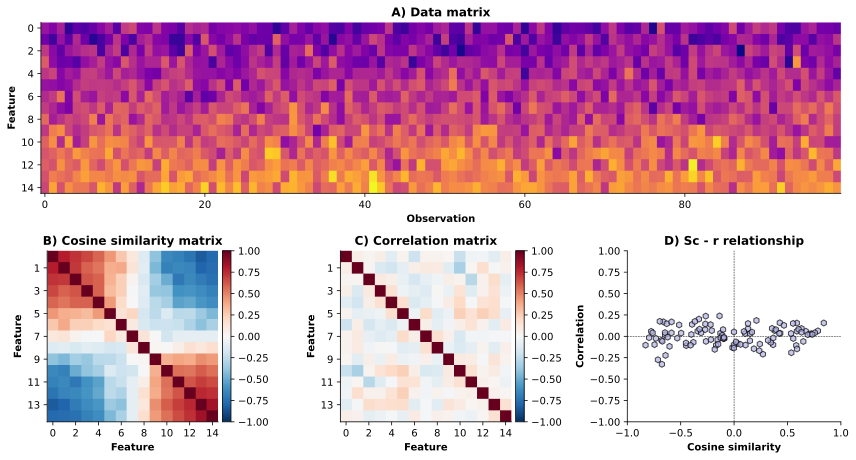

In [13]:
fig = plt.figure(figsize=(12, 6.5))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

ax1.imshow(X.T, aspect='auto', cmap='plasma')
ax1.set(xlabel='Observation', ylabel='Feature', title='A) Data matrix')

h = ax2.imshow(csM, vmin=-1, vmax=1, cmap="RdBu_r")
fig.colorbar(h, ax=ax2, pad=0.02)
ax2.set(xlabel='Feature', ylabel='Feature', xticks=range(0, m, 2), yticks=range(1, m, 2), title='B) Cosine similarity matrix')

h = ax3.imshow(R,vmin=-1,vmax=1,cmap='RdBu_r')
fig.colorbar(h,ax=ax3,pad=.02)
ax3.set(xlabel='Feature',ylabel='Feature',xticks=range(0,m,2),yticks=range(1,m,2), title='C) Correlation matrix')

unique_cs = csM[np.triu_indices(csM.shape[0], k=1)]
unique_rs = R[np.triu_indices(R.shape[0], k=1)]

ax4.axhline(0, linestyle='--', color='k', linewidth=.5)
ax4.axvline(0, linestyle='--', color='k', linewidth=.5)
ax4.plot(unique_cs, unique_rs, 'kh', markerfacecolor=[.7, .7, .9, .7])
ax4.set(xlabel='Cosine similarity', ylabel='Correlation', xlim=[-1, 1], ylim=[-1,1], title='D) Sc - r relationship')

plt.tight_layout()
plt.savefig('ch3_cossimB.png')
plt.show()

In [14]:
tokenpair = np.random.choice(np.arange(3000, 6001), 2)

In [15]:
word1  = 'sunshine'
word2 = 'pineapple'

In [16]:
for t in tokenpair:
    print(f'{t:5} is "{tokenizer.decode(t)}"')

 5219 is "session"
 4254 is "impact"


In [17]:
v1 = embeddings[tokenpair[0]]
v2 = embeddings[tokenpair[1]]

v1_token = tokenizer.decode(tokenpair[0])
v2_token = tokenizer.decode(tokenpair[1])

print(f'Token pair: "{v1_token}" and "{v2_token}"')
print(f'Embedding shape: {v1.shape}')

Token pair: "session" and "impact"
Embedding shape: torch.Size([768])


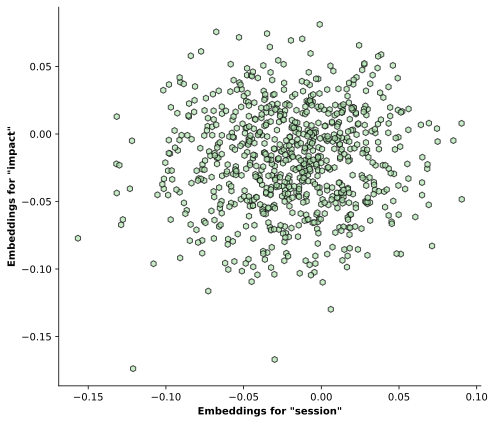

In [18]:
plt.figure(figsize=(7,6))

plt.plot(v1, v2, 'kh', markerfacecolor=[.7, .9, .7, .7])
plt.gca().set(xlabel=f'Embeddings for "{v1_token}"', ylabel=f'Embeddings for "{v2_token}"')

plt.tight_layout()
plt.savefig('ch3_proj8_part1.png')
plt.show()

In [19]:
num = torch.sum(v1*v2)
norm_v1 = torch.sqrt(torch.sum(v1**2))
norm_v2 = torch.linalg.norm(v2)
den = norm_v1 * norm_v2

print(f'Shape of vectors: {v1.shape}')
manual_cs = num/den

Shape of vectors: torch.Size([768])


In [20]:
v1_t = v1.unsqueeze(dim=0)
v2_t = v2.view(1,-1) 

print(f'Shape of torch vectors: {v1_t.shape}')
torch_cs = torch.cosine_similarity(v1_t,v2_t)

Shape of torch vectors: torch.Size([1, 768])


In [21]:
print(f'Manual cosine similarity:  {manual_cs:.5f}')
print(f'Pytorch cosine similarity: {torch_cs.item():.5f}')

Manual cosine similarity:  0.24412
Pytorch cosine similarity: 0.24412


In [22]:
E_norm = embeddings / torch.linalg.norm(embeddings, dim=1, keepdim=True)

csM = E_norm @ E_norm.T
print(f'Cosine similarity matrix shape: {csM.shape} ({np.prod(csM.shape):,} total elements!)')

Cosine similarity matrix shape: torch.Size([30522, 30522]) (931,592,484 total elements!)


In [24]:
csM = csM.to(torch.float16)

del E_norm

In [25]:
skip = 3
csMsub = csM[::skip, ::skip]

print(f'Full matrix shape: {csM.shape} ({np.prod(csM.shape):>11,} total elements!)')
print(f'Submatrix shape  : {csMsub.shape} ({np.prod(csMsub.shape):>11,} total elements!)')

Full matrix shape: torch.Size([30522, 30522]) (931,592,484 total elements!)
Submatrix shape  : torch.Size([10174, 10174]) (103,510,276 total elements!)


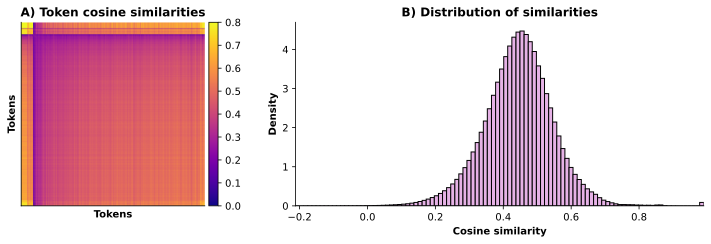

In [26]:
cs_nonredun = csMsub[np.triu_indices(csMsub.shape[0], k=1)]

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))

h = axs[0].imshow(csMsub, vmin=0, vmax=.8, cmap='plasma')
axs[0].set(title='A) Token cosine similarities', xticks=[], yticks=[], xlabel='Tokens', ylabel='Tokens')
plt.colorbar(h, ax=axs[0], pad=0.01)

axs[1].hist(cs_nonredun, bins=100, density=True, color=[.9, .7, .9], edgecolor='k')
axs[1].set(xlabel='Cosine similarity', ylabel='Density', xlim=[cs_nonredun.min(), cs_nonredun.max()], title='B) Distribution of similarities')

plt.tight_layout()
plt.savefig('ch3_proj8_part2.png')
plt.show()

In [27]:
for i in range(20):
    print(f'Token {i:2} is "{tokenizer.decode(i)}"')

Token  0 is "[PAD]"
Token  1 is "[unused0]"
Token  2 is "[unused1]"
Token  3 is "[unused2]"
Token  4 is "[unused3]"
Token  5 is "[unused4]"
Token  6 is "[unused5]"
Token  7 is "[unused6]"
Token  8 is "[unused7]"
Token  9 is "[unused8]"
Token 10 is "[unused9]"
Token 11 is "[unused10]"
Token 12 is "[unused11]"
Token 13 is "[unused12]"
Token 14 is "[unused13]"
Token 15 is "[unused14]"
Token 16 is "[unused15]"
Token 17 is "[unused16]"
Token 18 is "[unused17]"
Token 19 is "[unused18]"


In [28]:
unused_tokens = torch.zeros(tokenizer.vocab_size, dtype=bool)
for i in range(tokenizer.vocab_size):
    if '[unused' in tokenizer.decode(i):
        unused_tokens[i] = True

titleinfo = f'{unused_tokens.sum()}/{tokenizer.vocab_size} ({100*unused_tokens.sum()/tokenizer.vocab_size:.2f}%) "unused" tokens'

plt.figure(figsize=(10,3))
plt.plot(range(tokenizer.vocab_size), torch.randn(tokenizer.vocab_size)/40+unused_tokens, 'ko', markersize=2, markerfacecolor='w', alpha=.3)
plt.gca().set(xlabel='Token index', ylabel='Value', yticks=[0,1], yticklabels=['Used', 'Unused'], ylim=[-0.05, 1.5], xlim=[-15, len(unused_tokens)+15], title=titleinfo)

plt.tight_layout()
plt.savefig('ch3_proj8_part3.png')
plt.show()

In [29]:
csMsub = csM[unused_tokens, :][:, unused_tokens]

cs_nonredun = csMsub[np.triu_indices(csMsub.shape[0], k=1)]
cs_unique = np.unique(cs_nonredun)

print(f'There are {cs_nonredun.shape[0]:,} non-redundant values, {len(cs_unique)} of which are unique.')
print('\nThe unique values are:\n',cs_unique)

There are 493,521 non-redundant values, 13 of which are unique.

The unique values are:
 [0.9854 0.986  0.9863 0.987  0.9873 0.988  0.9883 0.989  0.9893 0.9897
 0.99   0.9907 0.991 ]


In [30]:
from transformers import GPT2Model
model = GPT2Model.from_pretrained('gpt2')

embeddings = model.wte.weight.detach()

skip = 5
embeddings = embeddings[::skip,:].to(torch.float16)
embeddings.shape

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1891.95it/s]


torch.Size([10052, 768])

In [31]:
E_norm = torch.nn.functional.normalize(embeddings, p=2, dim=1)

N = embeddings.shape[0]
block = 1024
csM = torch.empty(N, N, dtype=E_norm.dtype)

for i in tqdm(range(0, N, block)):
    end_i = min(i+block, N)
    cs_part = E_norm[i:end_i] @ E_norm.T
    csM[i:end_i] = cs_part

100%|██████████| 10/10 [00:04<00:00,  2.34it/s]


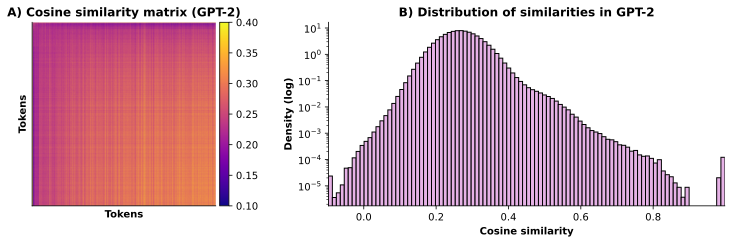

In [32]:
row, col = np.triu_indices(csM.shape[0], k=1)
cs_nonredun = csM[row, col]

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))

h = axs[0].imshow(csM, vmin=.1 , vmax=.4, cmap='plasma')
axs[0].set(title='A) Cosine similarity matrix (GPT-2)', xticks=[], yticks=[], xlabel='Tokens', ylabel='Tokens')
plt.colorbar(h, ax=axs[0], pad=0.01)

axs[1].hist(cs_nonredun,bins=100,density=True,color=[.9,.7,.9],edgecolor='k')
axs[1].set(xlabel='Cosine similarity',ylabel='Density (log)', xlim=[cs_nonredun.min(),cs_nonredun.max()],yscale='log', title='B) Distribution of similarities in GPT-2')

plt.tight_layout()
plt.savefig('ch3_proj8_part4.png')
plt.show()


In [33]:
E_norm = embeddings - embeddings.mean(dim=1, keepdim=True)
E_norm = torch.nn.functional.normalize(E_norm, p=2, dim=1)

R = torch.empty(N, N, dtype=E_norm.dtype)

for i in tqdm(range(0, N, block)):
    end_i = min(i+block, N)
    R_part = E_norm[i:end_i] @ E_norm.T
    R[i:end_i] = R_part

R_nonredun = R[row, col]

100%|██████████| 10/10 [00:04<00:00,  2.38it/s]


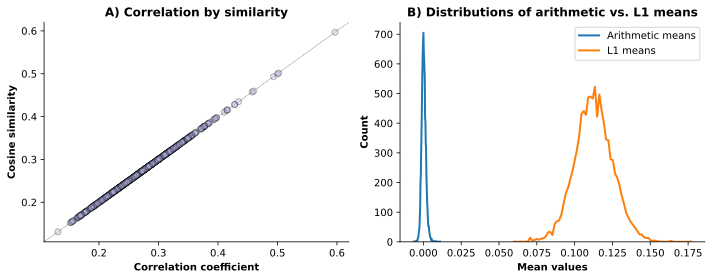

In [34]:
yAr,xAr = np.histogram(embeddings.mean(dim=1).numpy(),bins=80)
yL1,xL1 = np.histogram(abs(embeddings).mean(dim=1),bins=80)


fig,axs = plt.subplots(1,2,figsize=(10,4))

skip = 50000

axs[0].axline(np.full(2,R_nonredun[::skip].min().item()),slope=1,color='k',linestyle='--',linewidth=.3)

axs[0].plot(R_nonredun[::skip],cs_nonredun[::skip],'ko',markerfacecolor=[.7,.7,.9,.3])
axs[0].set(xlabel='Correlation coefficient',ylabel='Cosine similarity', title='A) Correlation by similarity')

axs[1].plot(xAr[:-1],yAr,linewidth=2,label='Arithmetic means')
axs[1].plot(xL1[:-1],yL1,linewidth=2,label='L1 means')
axs[1].legend()
axs[1].set(xlabel='Mean values',ylabel='Count',ylim=[0,None], title='B) Distributions of arithmetic vs. L1 means')

plt.tight_layout()
plt.savefig('ch3_proj8_part5.png')
plt.show()